In [1]:
import pandas as pd

df=pd.read_csv('spam.csv',encoding='latin-1')
df.sample(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
1534,ham,Remember on that day..,NaN,NaN,NaN
3415,ham,Uhhhhrmm isnt having tb test bad when youre sick,NaN,NaN,NaN
3825,ham,"Goodmorning,my grandfather expired..so am on l...",NaN,NaN,NaN
4234,spam,FREEMSG: Our records indicate you may be entit...,NaN,NaN,NaN
3274,ham,Hurry home u big butt. Hang up on your last ca...,NaN,NaN,NaN


In [10]:
df.shape

(5572, 5)

1. Data cleaning

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   v1          5572 non-null   str  
 1   v2          5572 non-null   str  
 2   Unnamed: 2  50 non-null     str  
 3   Unnamed: 3  12 non-null     str  
 4   Unnamed: 4  6 non-null      str  
dtypes: str(5)
memory usage: 677.1 KB


In [2]:
# delete null columns
df.drop(['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], axis=1, inplace=True)

# rename columns
df.rename(columns={'v1':'target', 'v2':'text'}, inplace=True)
df.head()

,target,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [3]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
encoder=OneHotEncoder()

df['target'] = encoder.fit_transform(df[['target']]).toarray()
df

,target,text
0,1.0,"Go until jurong point, crazy.. Available only ..."
1,1.0,Ok lar... Joking wif u oni...
2,0.0,Free entry in 2 a wkly comp to win FA Cup fina...
3,1.0,U dun say so early hor... U c already then say...
4,1.0,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,0.0,This is the 2nd time we have tried 2 contact u...
5568,1.0,Will Ì_ b going to esplanade fr home?
5569,1.0,"Pity, * was in mood for that. So...any other s..."
5570,1.0,The guy did some bitching but I acted like i'd...


In [70]:
# check duplicate values
df.duplicated().sum()

np.int64(403)

In [4]:
# revove duplicate values
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

2. EDA


In [52]:
df['target'].value_counts()

target
1.0    4516
0.0     653
Name: count, dtype: int64

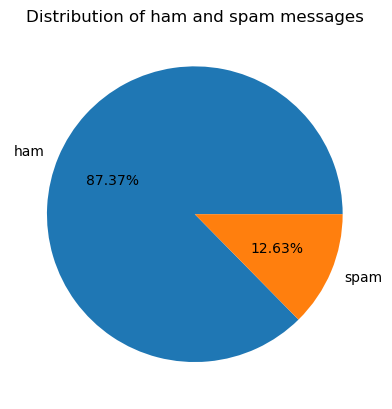

In [8]:
import matplotlib.pyplot as plt

plt.pie(df['target'].value_counts(), labels=['ham', 'spam'], autopct='%1.2f%%')
plt.title('Distribution of ham and spam messages')
plt.show()

In [5]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /Users/dipmondal/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/dipmondal/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [6]:
df['num_characters'] = df['text'].apply(len)

df['word_count'] = df['text'].apply(lambda x: len(nltk.word_tokenize(x)))
df['sentence_count'] = df['text'].apply(lambda x: len(nltk.sent_tokenize(x)))
df

,target,text,num_characters,word_count,sentence_count
0,1.0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,1.0,Ok lar... Joking wif u oni...,29,8,2
2,0.0,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,1.0,U dun say so early hor... U c already then say...,49,13,1
4,1.0,"Nah I don't think he goes to usf, he lives aro...",61,15,1
...,...,...,...,...,...
5567,0.0,This is the 2nd time we have tried 2 contact u...,161,35,4
5568,1.0,Will Ì_ b going to esplanade fr home?,37,9,1
5569,1.0,"Pity, * was in mood for that. So...any other s...",57,15,2
5570,1.0,The guy did some bitching but I acted like i'd...,125,27,1


In [74]:
df[['num_characters', 'word_count', 'sentence_count']].describe()

,num_characters,word_count,sentence_count
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [33]:
# ham messages
filt=df['target'] == 1
df[filt][['num_characters', 'word_count', 'sentence_count']].describe()


,num_characters,word_count,sentence_count
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [24]:
# spam messages
df[~filt][['num_characters', 'word_count', 'sentence_count']].describe()

,num_characters,word_count,sentence_count
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


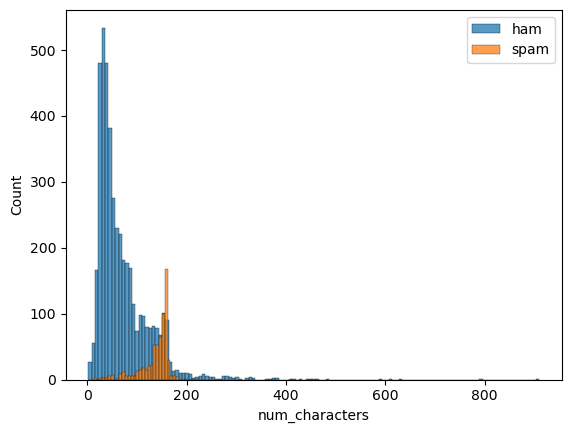

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.histplot(df[df['target'] == 1]['num_characters'], label='ham') 
sns.histplot(df[df['target'] == 0]['num_characters'], label='spam')
plt.legend()

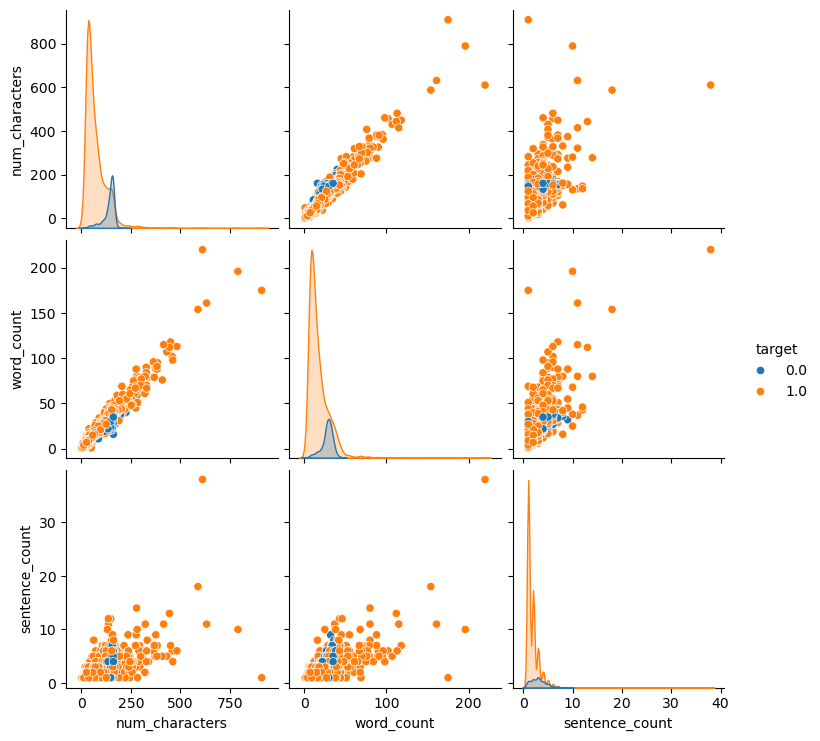

In [37]:
sns.pairplot(df, hue='target')

<Axes: >

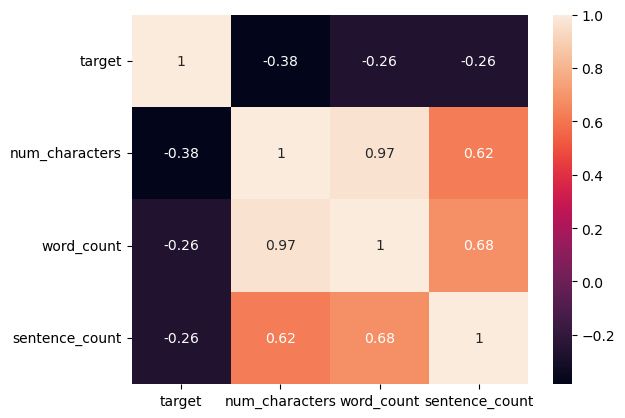

In [40]:
cor = df.drop(['text'], axis=1).corr()
sns.heatmap(cor, annot=True)


### Data Preprocessing
• Lower case<br>
• Tokenization<br>
• Removing special characters<br>
• Removing stop words and punctuation <br>
• Stemming

In [7]:
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
import string
nltk.download('stopwords')
ps = PorterStemmer()

def text_transformed(text):
    text=text.lower() # convert text to lowercase
    text= nltk.word_tokenize(text) # tokenize the text
    y=[]
    for i in text:
        if i.isalnum(): # remove special characters
            y.append(i)
    text=y[:]
    y.clear()
    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation: # remove stop words and punctuation
            y.append(ps.stem(i)) # stemming
    
    return " ".join(y)

text_transformed("Lello i am dipmondal and i am learning nlp")

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/dipmondal/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


'lello dipmond learn nlp'

In [9]:
df['transformed_text']=df['text'].apply(text_transformed)
df

,target,text,num_characters,word_count,sentence_count,transformed_text
0,1.0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,1.0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,0.0,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,1.0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,1.0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though
...,...,...,...,...,...,...
5567,0.0,This is the 2nd time we have tried 2 contact u...,161,35,4,2nd time tri 2 contact u pound prize 2 claim e...
5568,1.0,Will Ì_ b going to esplanade fr home?,37,9,1,b go esplanad fr home
5569,1.0,"Pity, * was in mood for that. So...any other s...",57,15,2,piti mood suggest
5570,1.0,The guy did some bitching but I acted like i'd...,125,27,1,guy bitch act like interest buy someth els nex...


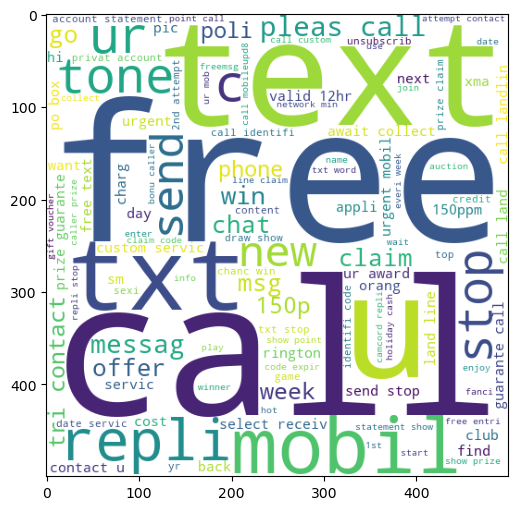

In [ ]:
from wordcloud import WordCloud
wc=WordCloud(width=500, height=500, min_font_size=10, background_color='white')
spam_wc=wc.generate(df[df['target'] == 0]['transformed_text'].str.cat(sep=" "))

plt.figure(figsize=(15,6))
plt.imshow(spam_wc)

(np.float64(-0.5), np.float64(499.5), np.float64(499.5), np.float64(-0.5))

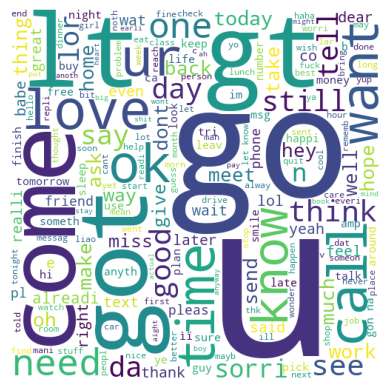

In [71]:
ham_wc=wc.generate(df[df['target'] == 1]['transformed_text'].str.cat(sep=" "))
plt.imshow(ham_wc)
plt.axis('off')

In [76]:
from collections import Counter
spam_count=[]
for msg in df[df['target'] == 0]['transformed_text'].tolist():
    for i in msg.split():
        spam_count.append(i)
spam_count

['free',
 'entri',
 '2',
 'wkli',
 'comp',
 'win',
 'fa',
 'cup',
 'final',
 'tkt',
 '21st',
 'may',
 'text',
 'fa',
 '87121',
 'receiv',
 'entri',
 'question',
 'std',
 'txt',
 'rate',
 'c',
 'appli',
 '08452810075over18',
 'freemsg',
 'hey',
 'darl',
 '3',
 'week',
 'word',
 'back',
 'like',
 'fun',
 'still',
 'tb',
 'ok',
 'xxx',
 'std',
 'chg',
 'send',
 'rcv',
 'winner',
 'valu',
 'network',
 'custom',
 'select',
 'receivea',
 'prize',
 'reward',
 'claim',
 'call',
 'claim',
 'code',
 'kl341',
 'valid',
 '12',
 'hour',
 'mobil',
 '11',
 'month',
 'u',
 'r',
 'entitl',
 'updat',
 'latest',
 'colour',
 'mobil',
 'camera',
 'free',
 'call',
 'mobil',
 'updat',
 'co',
 'free',
 '08002986030',
 'six',
 'chanc',
 'win',
 'cash',
 '100',
 'pound',
 'txt',
 'csh11',
 'send',
 'cost',
 '6day',
 'tsandc',
 'appli',
 'repli',
 'hl',
 '4',
 'info',
 'urgent',
 '1',
 'week',
 'free',
 'membership',
 'prize',
 'jackpot',
 'txt',
 'word',
 'claim',
 '81010',
 'c',
 'lccltd',
 'pobox',
 '4403ldnw

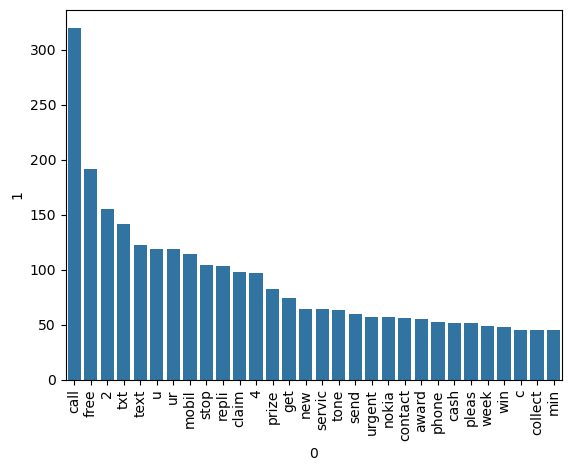

In [87]:
df=pd.DataFrame(Counter(spam_count).most_common(30))    
sns.barplot(x=df[0], y=df[1])
plt.xticks(rotation='vertical')
plt.show()

4. model

In [1]:
from sklearn.feature_extraction.text import TfidfVectorizer,CountVectorizer
tfidf=TfidfVectorizer(max_features=3000)
cv=CountVectorizer()

X = cv.fit_transform(df['transformed_text']).toarray()
y=df['target']
X

NameError: name 'df' is not defined

In [75]:
tfidf = TfidfVectorizer()
X = tfidf.fit_transform(df['transformed_text'])
y=df['target']

In [80]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2, random_state=2)

In [81]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score

lgs=LogisticRegression()

lgs.fit(X_train,y_train)

pred=lgs.predict(X_test)
print(accuracy_score(y_test,pred))
print(confusion_matrix(y_test,pred))
print(precision_score(y_test,pred))


0.9787234042553191
[[117  21]
 [  1 895]]
0.9770742358078602


In [78]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score

svm=SVC(kernel='sigmoid')

svm.fit(X_train,y_train)

pred=svm.predict(X_test)
print(accuracy_score(y_test,pred))
print(confusion_matrix(y_test,pred))
print(precision_score(y_test,pred))


0.9729206963249516
[[113  25]
 [  3 893]]
0.9727668845315904


In [65]:
import pickle
pickle.dump(cv, open('vectorizer.pkl', 'wb'))
pickle.dump(lgs, open('model.pkl', 'wb'))